# Volume — styler settings

Companion to `candlesticks-styles.ipynb` / `ohlc-styles.ipynb`: the `Volume` settings hook — `volume.up.color` / `volume.down.color` / `volume.ma.color` (independent per-element params: kwarg → setting → `~`-snapped default) and `volume.alpha` (kwarg → setting → 0.5, bars and ma line). Bars color by bar direction (close ≥ open, matching the candlesticks); explicit kwargs are exact colors — only the defaults snap to the prop cycle.

In [1]:
from mplchart.chart import Chart
from mplchart.primitives import Candlesticks, Volume
from mplchart.samples import sample_prices
from mplchart.styles import available_styles, get_styler

prices = sample_prices().tail(60)
prices.tail()

,open,high,low,close,volume
date,,,,,
2025-11-11,269.809998,275.910004,269.799988,275.250000,46208300
2025-11-12,275.000000,275.730011,271.700012,273.470001,48398000
2025-11-13,274.109985,276.700012,272.089996,272.950012,49602800
2025-11-14,271.049988,275.959991,269.600006,272.410004,47399300
2025-11-17,268.815002,270.489990,265.730011,267.459991,42862157


In [2]:
def show_volume(prices, title, settings=(), style=None, **kwargs):
    """Plot candles + volume under a style — a spec via style=, or settings."""
    if style is None:
        style = get_styler('mplchart', overrides=settings)
    chart = Chart(prices, figsize=(12, 4), title=title, style=style)
    chart.plot(Candlesticks(), Volume(**kwargs))
    chart.show()

## Kwargs and settings

Three independent color elements (up bars, down bars, ma line) — each kwarg overrides only its own setting, nothing is atomic.

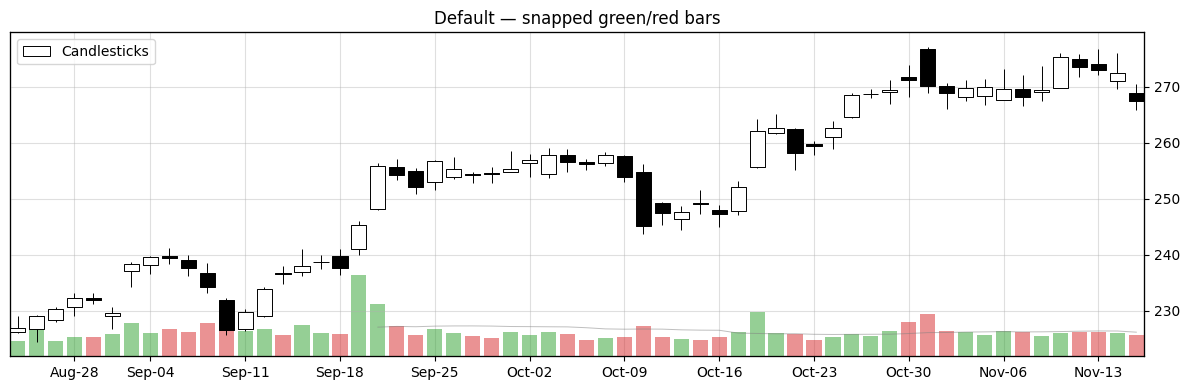

In [3]:
show_volume(prices, "Default — snapped green/red bars", sma=20)

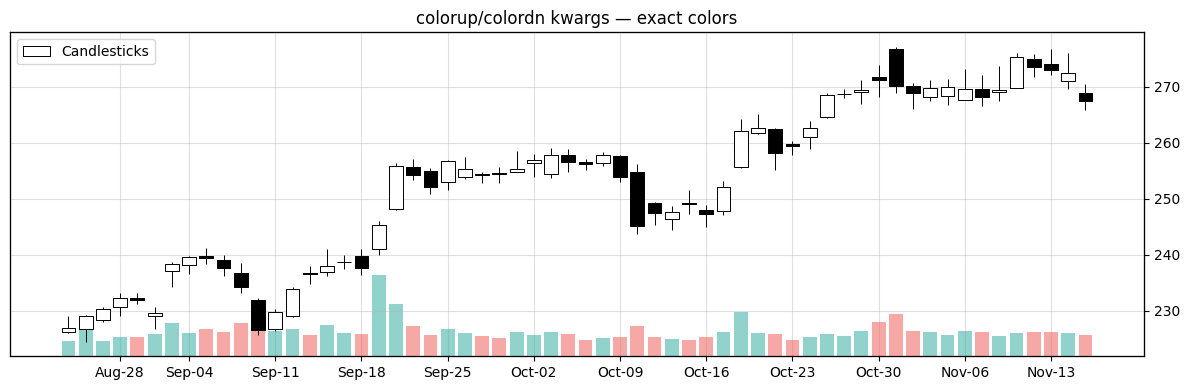

In [4]:
show_volume(prices, "colorup/colordn kwargs — exact colors",
            colorup="#26a69a", colordn="#ef5350")

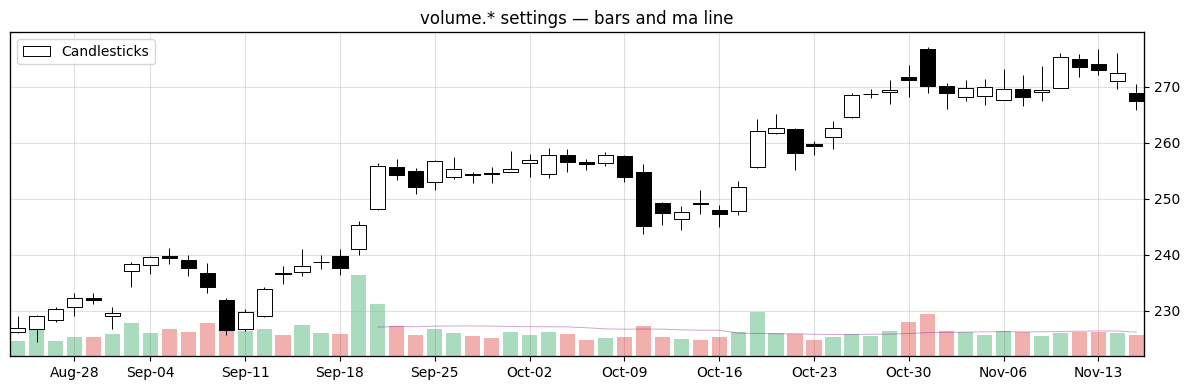

In [5]:
show_volume(prices, "volume.* settings — bars and ma line",
            {"volume.up.color": "#0f9948", "volume.down.color": "#d91e18",
             "volume.ma.color": "purple", "volume.alpha": 0.35},
            sma=20)

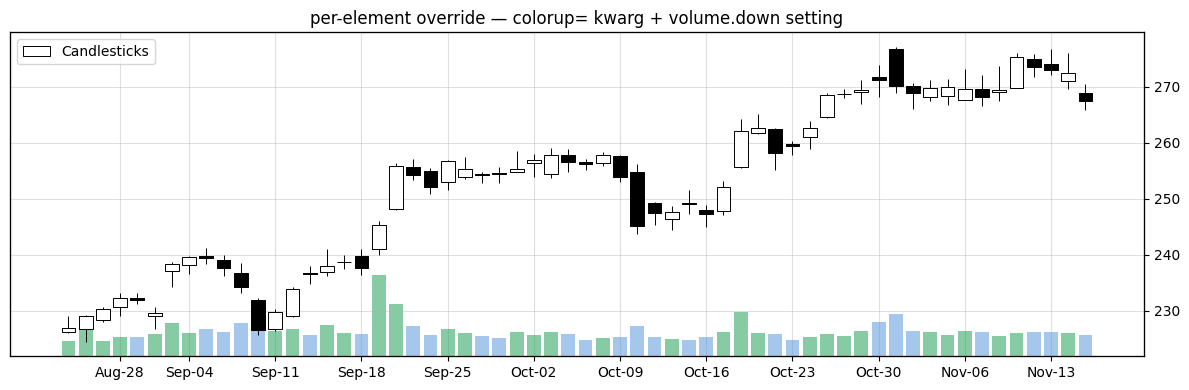

In [6]:
show_volume(prices, "per-element override — colorup= kwarg + volume.down setting",
            {"volume.down.color": "#4a90d9"}, colorup="#0f9948")

## Shipped styles

Every shipped style declares its volume palette alongside candle/ohlc keys (roles independent — no cross-role fallback).

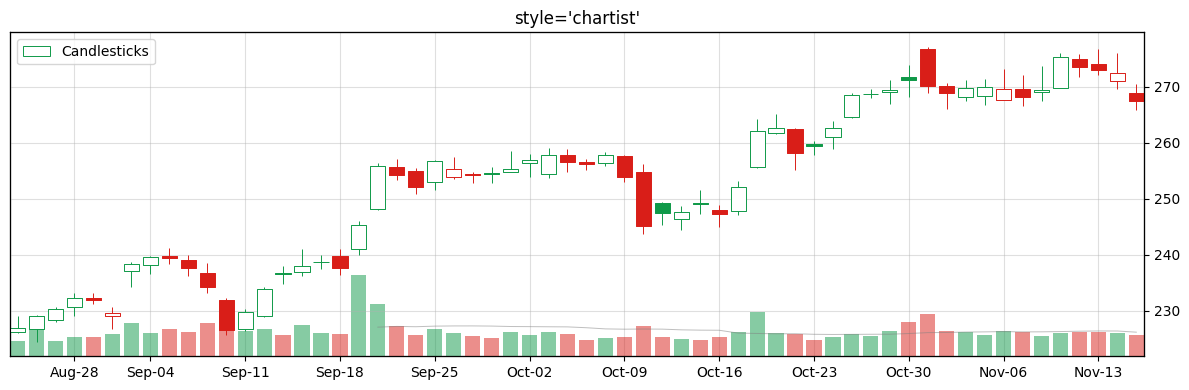

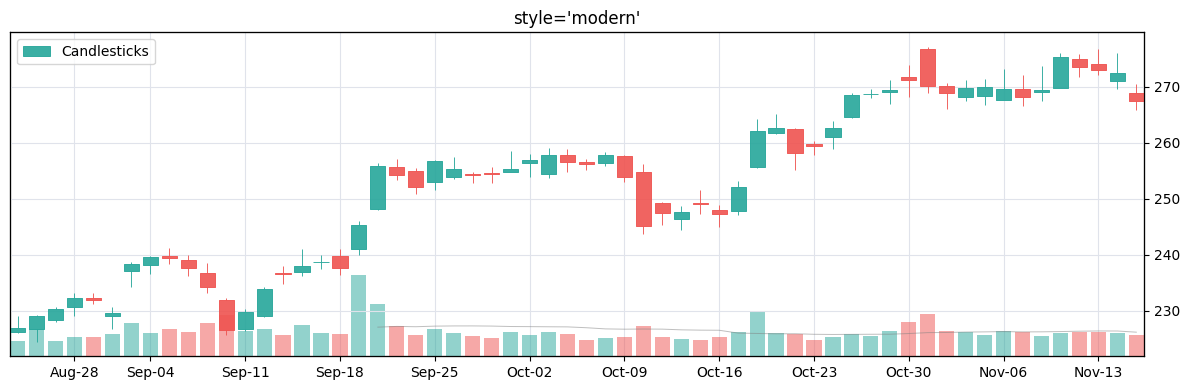

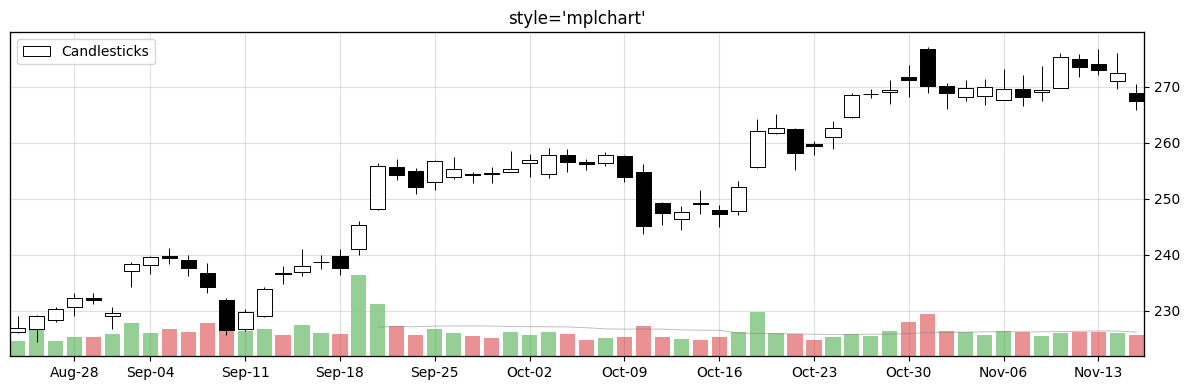

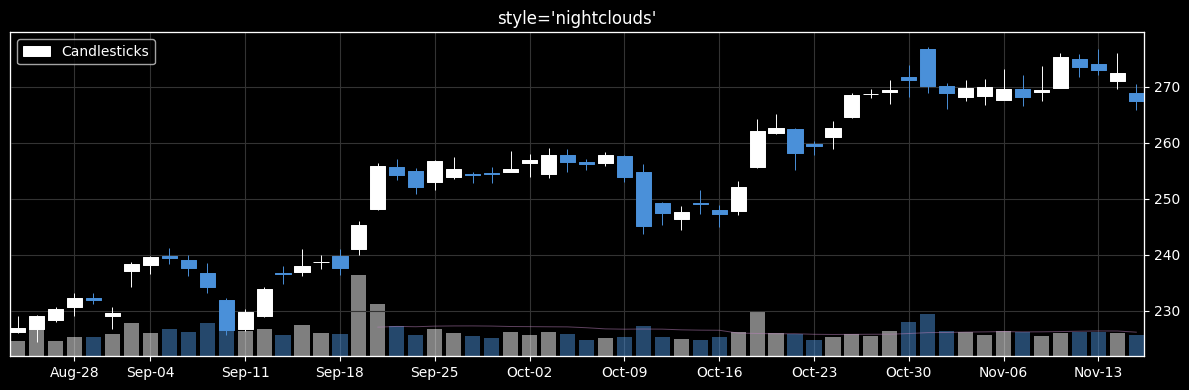

In [7]:
for name in available_styles():
    show_volume(prices, f"style={name!r}", style=name, sma=20)